In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,roc_curve,roc_auc_score,classification_report
print("Classification Libraries Sucessfully Imported!")

Classification Libraries Sucessfully Imported!


In [5]:
df=pd.read_csv('Heart_Disease_Prediction.csv')
print(df.isnull().sum())

Age                        1
Gender                     1
Chest pain type            2
BP                         1
Cholesterol                1
FBS over 120               1
EKG results                1
Max HR                     1
Exercise angina            1
ST depression              1
Slope of ST                1
Number of vessels fluro    1
Thallium                   1
Heart Disease              1
dtype: int64


In [6]:
df.head()

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0,Presence
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,Absence
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0,Presence
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0,Absence
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0,Absence


Hum 'Heart Disease' column ko classification ke liye use kar rahe hain.


C:\Users\Humna Sarfraz\AppData\Local\Temp\ipykernel_18812\2445319915.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=actual_target_column, palette='Set2')


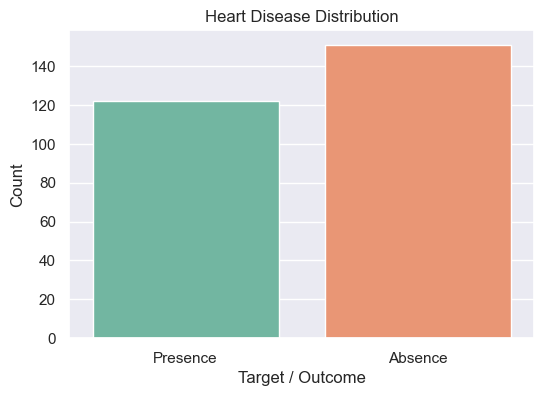

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")
plt.figure(figsize=(6, 4))
actual_target_column = df.columns[-1]
sns.countplot(data=df, x=actual_target_column, palette='Set2')
plt.title('Heart Disease Distribution')
plt.xlabel('Target / Outcome')
plt.ylabel('Count')
plt.show()

In [12]:
print(df.columns.tolist())
df.columns = df.columns.str.lower().str.strip()
df.rename(columns={df.columns[-1]: 'target'}, inplace=True)
if 'age' not in df.columns:
    age_col = [col for col in df.columns if 'age' in col]
    if age_col:
        df.rename(columns={age_col[0]: 'age'}, inplace=True)

print("Columns successfully renamed!")
print("New Columns:", df.columns.tolist())

['Age', 'Gender', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']
Columns successfully renamed!
New Columns: ['age', 'gender', 'chest pain type', 'bp', 'cholesterol', 'fbs over 120', 'ekg results', 'max hr', 'exercise angina', 'st depression', 'slope of st', 'number of vessels fluro', 'thallium', 'target']


In [20]:
print(X.isnull().sum().sum())
print(y.isnull().sum())
df.dropna(inplace=True)
X=df.drop(columns='target')
y=df['target']

14
1


In [24]:

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
model=LogisticRegression(max_iter=2000)
model.fit(X_train,y_train)
print("Sucessfully Trained")

Sucessfully Trained


Model Accuracy:85.45%

              precision    recall  f1-score   support

     Absence       0.92      0.80      0.86        30
    Presence       0.79      0.92      0.85        25

    accuracy                           0.85        55
   macro avg       0.86      0.86      0.85        55
weighted avg       0.86      0.85      0.85        55



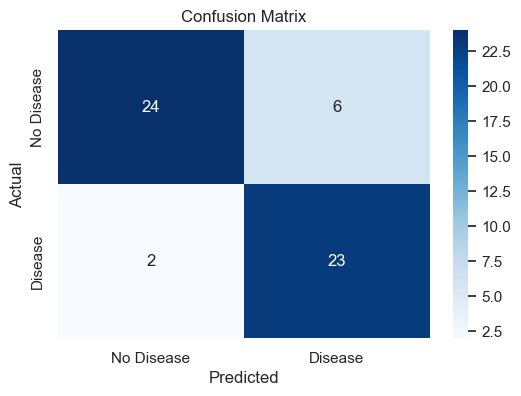

In [25]:
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"Model Accuracy:{accuracy*100:.2f}%\n")
print(classification_report(y_test,y_pred))
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [28]:
df.columns=df.columns.str.lower().str.strip()
df.rename(columns={df.columns[-1]:'target'},inplace=True)

if 'age' not in df.columns:
    age_col=[col for col in df.columns if 'age' in col]
    if age_col:
        df.rename(columns={age_col[0]:'age'},inplace=True)

df.dropna(inplace=True)

if df['target'].dtype=='object':
    df['target']=df['target'].map({'Absence':0,'Presence':1})

X=df.drop(columns='target')
y=df['target']

sns.set_theme(style="darkgrid")
print("Dataset setup completed successfully")

Dataset setup completed successfully


C:\Users\Humna Sarfraz\AppData\Local\Temp\ipykernel_18812\678467275.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='target',palette='Set2')


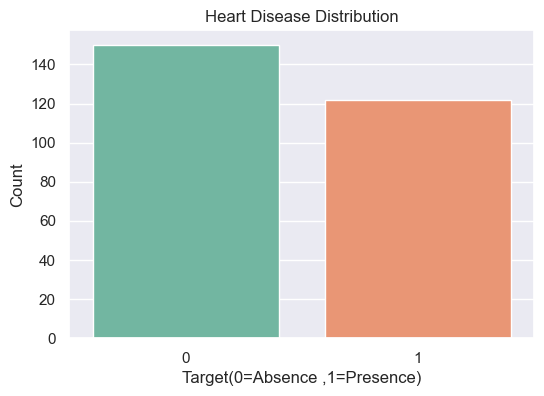

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='target',palette='Set2')
plt.title('Heart Disease Distribution')
plt.xlabel('Target(0=Absence ,1=Presence)')
plt.ylabel('Count')
plt.show()

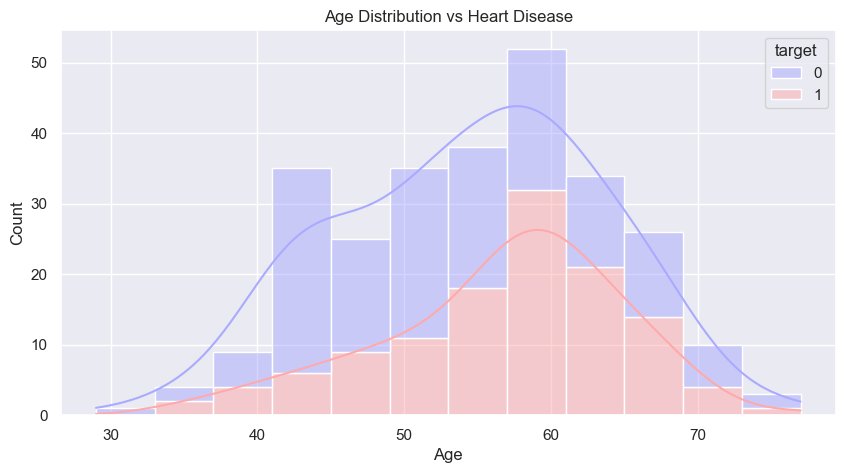

In [30]:
plt.figure(figsize=(10,5))
sns.histplot(data=df,x='age',hue='target',multiple='stack',kde=True,palette='bwr')
plt.title('Age Distribution vs Heart Disease')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [33]:
X_train,X_test,y_tarin,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
model=LogisticRegression(max_iter=2000)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

accuracy=accuracy_score(y_test,y_pred)
print(f"Model Accuracy:{accuracy*100:.2f}%\n")

print("Classification Report")
print(classification_report(y_test,y_pred))

Model Accuracy:85.45%

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        30
           1       0.79      0.92      0.85        25

    accuracy                           0.85        55
   macro avg       0.86      0.86      0.85        55
weighted avg       0.86      0.85      0.85        55



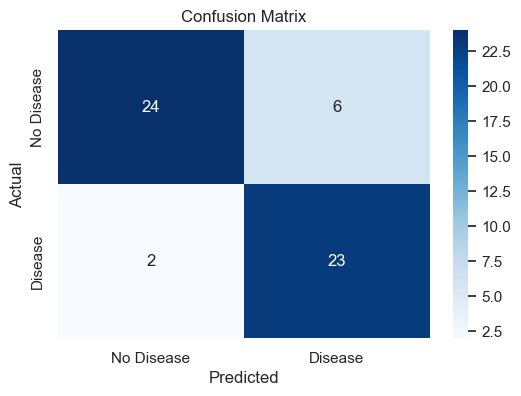

In [35]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


ValueError: 'lower rigt' is not a valid value for loc; supported values are 'best', 'upper right', 'upper left', 'lower left', 'lower right', 'right', 'center left', 'center right', 'lower center', 'upper center', 'center'

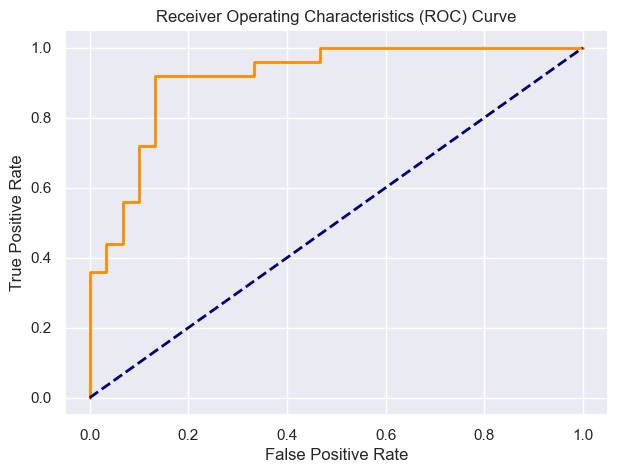

In [36]:
y_pred_prob=model.predict_proba(X_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_pred_prob)
auc_score=roc_auc_score(y_test,y_pred_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,color='darkorange',lw=2,label=f'ROC Curve (AUC ={auc_score:.2f})')
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--')
plt.title('Receiver Operating Characteristics (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower rigt")
plt.show()

C:\Users\Humna Sarfraz\AppData\Local\Temp\ipykernel_18812\571758043.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance,x='Importance',y='Feature',palette='viridis')


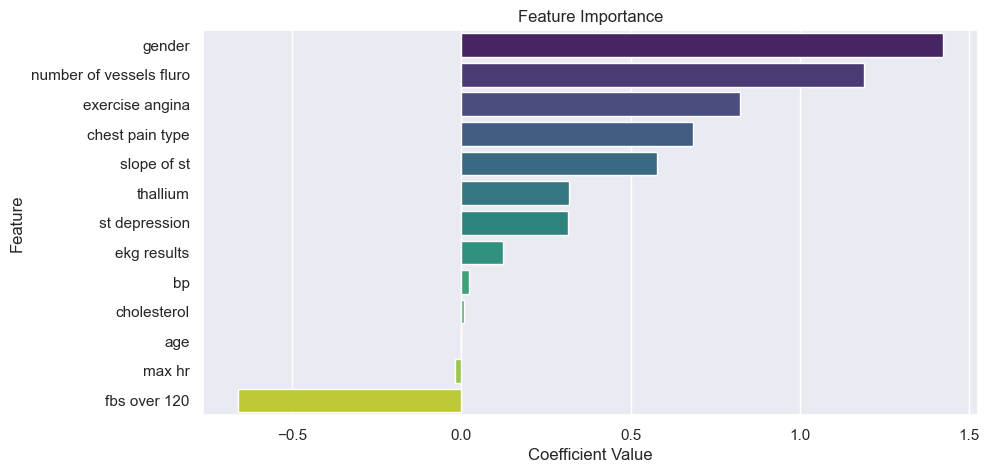

In [37]:
coefficients=model.coef_[0]
feature_importance=pd.DataFrame({'Feature':X.columns,'Importance':coefficients})
feature_importance=feature_importance.sort_values(by='Importance',ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=feature_importance,x='Importance',y='Feature',palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()